# **Cardiovascular Disease Risk Prediction**
Cardio vascular disease is one of leading health problem that is affecting many people across age groups. It depends on sevarl factors like obesity, diabetes, smoking, diet, etc. Below is an attemp build a machine learning model to predict cardio vasculat disease using a publicallu available dataset. This data set is taken from
https://www.kaggle.com/datasets/harshwardhanfartale/cardiovascular-disease-risk-prediction-dataset

A typical Machine Learning life cycle is shown below
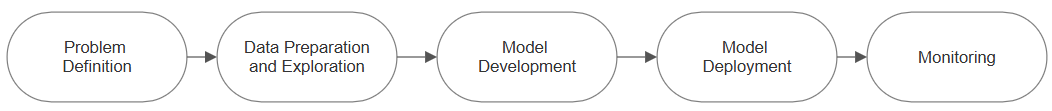

In this study KNearesrNeighbor, Support Vector Machine and GaussianNB were evaluated and based on model accuracy Support Vector Machine was used.

Disclaimer : Data set contains features on diet like fruit and vegetable consumption and due to lack of clarity on details that is omitted from model building.


# 1. Import required Python libraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')

# 2.Data Preparation and Exploration

In [ ]:
df = pd.read_csv('/content/sample_data/CVD_cleaned.csv')
df.head(5)

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109716 entries, 0 to 109715
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                109716 non-null  object 
 1   Checkup                       109716 non-null  object 
 2   Exercise                      109715 non-null  object 
 3   Heart_Disease                 109715 non-null  object 
 4   Skin_Cancer                   109715 non-null  object 
 5   Other_Cancer                  109715 non-null  object 
 6   Depression                    109715 non-null  object 
 7   Diabetes                      109715 non-null  object 
 8   Arthritis                     109715 non-null  object 
 9   Sex                           109715 non-null  object 
 10  Age_Category                  109715 non-null  object 
 11  Height_(cm)                   109715 non-null  float64
 12  Weight_(kg)                   109715 non-nul

In [ ]:
df.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,109715.000000,109715.000000,109715.000000,109715.000000,109715.000000,109715.000000,109715.000000
mean,170.570405,83.257609,28.526698,5.189473,29.760124,15.182919,6.251479
std,10.681524,21.360521,6.538385,8.312508,24.790391,14.926712,8.526683
min,91.000000,25.400000,12.160000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.130000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.190000,27.410000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.650000,6.000000,30.000000,20.000000,8.000000
max,234.000000,293.020000,98.440000,30.000000,120.000000,120.000000,128.000000


In [ ]:
df.shape

(109716, 19)

In [ ]:
df1 = df.dropna()
df1.shape

(109715, 19)

1)It is found from below chart on general heath versus gender that females seem to have better general heath compared to males

2)People with good, very good and excellent general heath status show less arthritis. Fair and poor heath condition shows more people with arthritis

3)It shows that regular execrcise helps keep fit and health as depcited by good, very good and excellent general heath status

4)Very few reported diabetic who have good, very good and excellent heath condition.

5)Depression is show by small percentage of people.It can be one of the reason for cardio disases

6)Small percentage of people have skin and other types of cancer

7)Smoking is big contributor to cardio disases and nearly 50% of people seems to have habit of smoking

Conclusion from these charts shows that taking care of health is very important to remain free from morbities






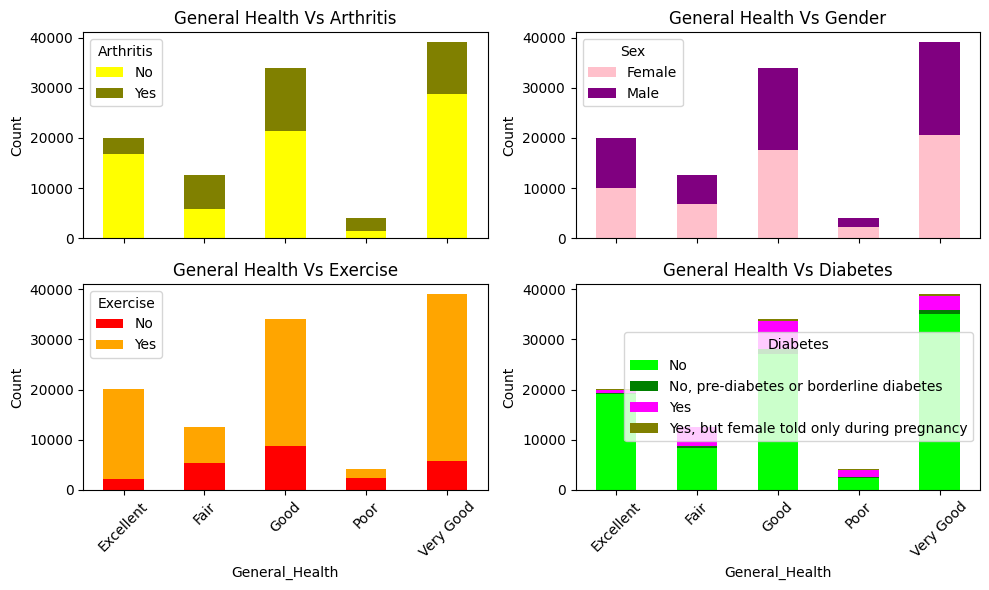

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

# Aggregate data by General Health
df_ar_counts = df1.groupby(["General_Health", "Arthritis"]).size().unstack(fill_value=0)
df_se_counts = df1.groupby(["General_Health", "Sex"]).size().unstack(fill_value=0)
df_ex_counts = df1.groupby(["General_Health", "Exercise"]).size().unstack(fill_value=0)
df_db_counts = df1.groupby(["General_Health", "Diabetes"]).size().unstack(fill_value=0)

# Plot on the axes
df_ar_counts.plot(kind="bar", stacked=True, ax=axes[0][0], color=["yellow", "olive"])
axes[0][0].set_title("General Health Vs Arthritis")
axes[0][0].set_ylabel("Count")
axes[0][0].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

df_se_counts.plot(kind="bar", stacked=True, ax=axes[0][1], color=["pink", "purple"])
axes[0][1].set_title("General Health Vs Gender")
axes[0][1].set_ylabel("Count")
axes[0][1].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

df_ex_counts.plot(kind="bar", stacked=True, ax=axes[1][0], color=["red", "orange"])
axes[1][0].set_title("General Health Vs Exercise")
axes[1][0].set_ylabel("Count")
axes[1][0].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

df_db_counts.plot(kind="bar", stacked=True, ax=axes[1][1], color=["lime", "green","Fuchsia","Olive"])
axes[1][1].set_title("General Health Vs Diabetes")
axes[1][1].set_ylabel("Count")
axes[1][1].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

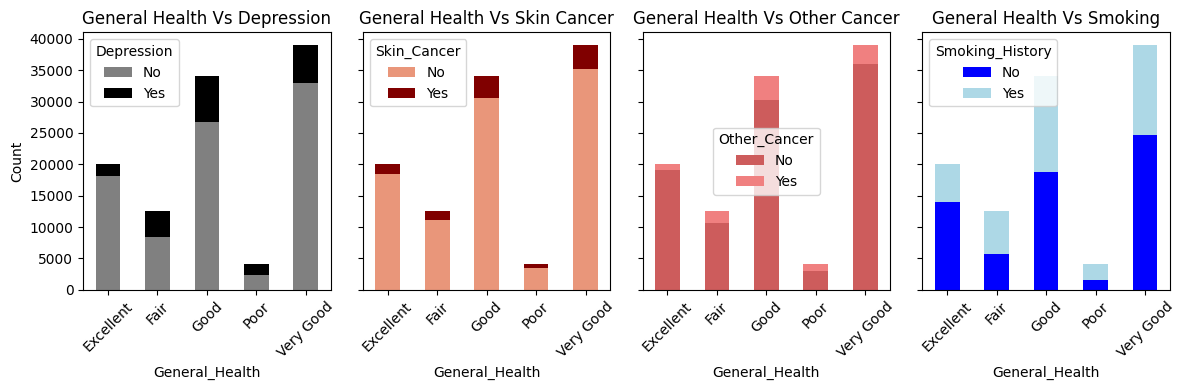

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)

df_dep_counts = df1.groupby(["General_Health", "Depression"]).size().unstack(fill_value=0)
df_sc_counts = df1.groupby(["General_Health", "Skin_Cancer"]).size().unstack(fill_value=0)
df_oc_counts = df1.groupby(["General_Health", "Other_Cancer"]).size().unstack(fill_value=0)
df_ac_counts = df1.groupby(["Age_Category","Heart_Disease"]).size().unstack(fill_value=0)
df_sm_counts = df1.groupby(["General_Health", "Smoking_History"]).size().unstack(fill_value=0)


df_dep_counts.plot(kind="bar", stacked=True, ax=axes[0], color=["grey", "black"])
axes[0].set_title("General Health Vs Depression")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

df_sc_counts.plot(kind="bar", stacked=True, ax=axes[1], color=["DarkSalmon", "Maroon"])
axes[1].set_title("General Health Vs Skin Cancer")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

df_oc_counts.plot(kind="bar", stacked=True, ax=axes[2], color=["IndianRed", "LightCoral"])
axes[2].set_title("General Health Vs Other Cancer")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=45)

df_sm_counts.plot(kind="bar", stacked=True, ax=axes[3], color=["Blue", "LightBlue"])
axes[3].set_title("General Health Vs Smoking")
axes[3].set_ylabel("Count")
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Below pie chart shows age group versus heart disease. It is clear with advancing age risk of hear diseases increases. People whi are in 50-54 age category need to be caution and may need regular cardio vascular heath check up

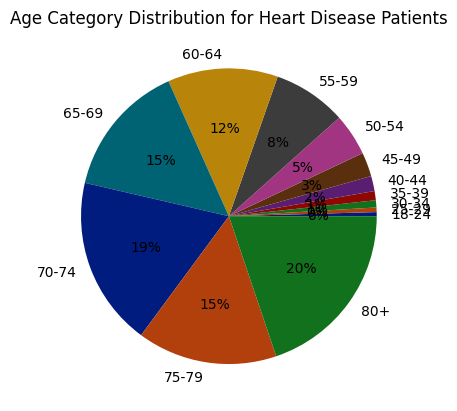

In [ ]:
df_ac_counts = df1.groupby(["Age_Category","Heart_Disease"]).size().unstack(fill_value=0)
df_ac_counts_A = df_ac_counts.drop(columns="No")
import seaborn as sns
colors = sns.color_palette('dark')

# Define explode with a length equal to the number of age categories
explode = [0] * len(df_ac_counts_A)

plt.pie(df_ac_counts_A['Yes'], labels=df_ac_counts_A.index, colors=colors, explode=explode, autopct='%.0f%%')
plt.title("Age Category Distribution for Heart Disease Patients") # Add a title for clarity
plt.show()

Below charts show

1)Half of the people with heart disease are diabetic. A significant number of non-diabetic have heart disese

2)Smoking and heart disese are closly linked

3)There are significant number of people who exercise and still have heart disease compared to who do not exercise. This needed further investigation

4)Obesity play key role in cardio vascular diseases. People who are obese have hear disease. Suprisingly people who have normal level of obesity are shown to be equal to obseity class 1. THis may need some deep dive to undertsnad futher

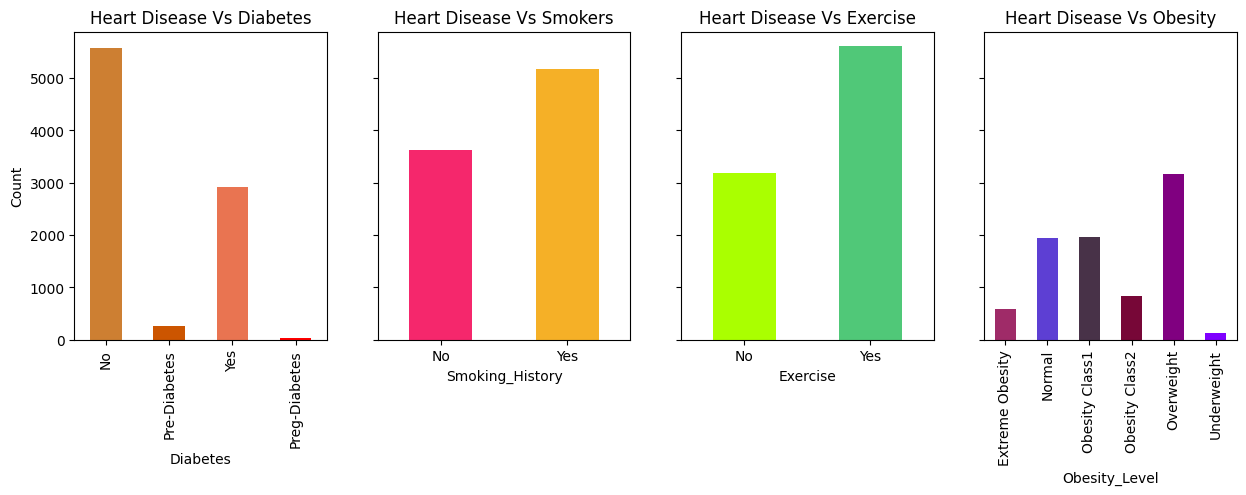

In [ ]:
def bmi_cat(bmi_no):
  if bmi_no < 18.5:
    return "Underweight"
  elif bmi_no >=18.5 and bmi_no < 24.9:
    return "Normal"
  elif bmi_no >=25 and bmi_no < 29.9:
    return "Overweight"
  elif bmi_no >= 30 and bmi_no < 34.9:
    return "Obesity Class1"
  elif bmi_no >=35 and bmi_no < 39.9:
    return "Obesity Class2"
  elif bmi_no > 40:
    return "Extreme Obesity"

df1["Obesity_Level"] = df1["BMI"].apply(bmi_cat)

df_ob = df1[["Heart_Disease","Diabetes","Smoking_History","Exercise","Obesity_Level"]]
df_cv = df_ob[df_ob["Heart_Disease"] == "Yes"]
dfcvd = df_cv.groupby(["Diabetes"]).size()
dfcvs = df_cv.groupby(["Smoking_History"]).size()
dfcve = df_cv.groupby(["Exercise"]).size()
dfcvo = df_cv.groupby(["Obesity_Level"]).size()

dfcvd.rename(index={"No, pre-diabetes or borderline diabetes": "Pre-Diabetes"}, inplace=True)
dfcvd.rename(index={"Yes, but female told only during pregnancy": "Preg-Diabetes"}, inplace=True)
fig, axes = plt.subplots(1, 4, figsize=(15, 4),sharey=True)

dfcvd.plot(kind="bar", ax=axes[0], color=["#CD7F32", "#CC5500","#E97451","red"])
axes[0].set_title("Heart Disease Vs Diabetes")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=90)

dfcvs.plot(kind="bar", ax=axes[1], color=["#F5276C", "#F5B027"])
axes[1].set_title("Heart Disease Vs Smokers")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=360)

dfcve.plot(kind="bar", ax=axes[2], color=["#AAFF00", "#50C878"])
axes[2].set_title("Heart Disease Vs Exercise")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=360)

dfcvo.plot(kind="bar", ax=axes[3], color=["#9F2B68", "#5D3FD3","#483248","#770737","#800080","#7F00FF"])
axes[3].set_title("Heart Disease Vs Obesity")
axes[3].set_ylabel("Count")
axes[3].tick_params(axis='x', rotation=90)

Machine Learning algoriths work with numbers. IN below code feature values are converted into numericals using LabelEncoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder
df2 = df1[["Checkup","Exercise","Heart_Disease","Skin_Cancer","Other_Cancer","Depression","Diabetes",
           "Arthritis","Sex","Age_Category","Height_(cm)","Weight_(kg)","BMI","Smoking_History",
           "Alcohol_Consumption","Fruit_Consumption","Green_Vegetables_Consumption","FriedPotato_Consumption"]]
le_cvd = LabelEncoder()
df2["Heart_Disease_YN"] = le_cvd.fit_transform(df2["Heart_Disease"])
df2["Diabetes_YN"] = le_cvd.fit_transform(df2["Diabetes"])
df2["Depression_YN"] = le_cvd.fit_transform(df2["Depression"])
df2["Arthritis_YN"] = le_cvd.fit_transform(df2["Arthritis"])
df2["Exercise_YN"] = le_cvd.fit_transform(df2["Exercise"])
df2["Skin_Cancer_YN"] = le_cvd.fit_transform(df2["Skin_Cancer"])
df2["Other_Cancer_YN"] = le_cvd.fit_transform(df2["Other_Cancer"])
df2["Exercise_YN"] = le_cvd.fit_transform(df2["Exercise"])
df2["Sex_YN"] = le_cvd.fit_transform(df2["Sex"])
df2["Age_Category_YN"] = le_cvd.fit_transform(df2["Age_Category"])
df2["Obesity_Level"] = df2["BMI"].apply(bmi_cat)
df2["Obesity_Level_YN"] = le_cvd.fit_transform(df2["Obesity_Level"])
df_final = df2[['Heart_Disease_YN', 'Diabetes_YN', 'Depression_YN', 'Arthritis_YN',
       'Exercise_YN', 'Skin_Cancer_YN', 'Other_Cancer_YN', 'Sex_YN',
       'Age_Category_YN','Obesity_Level_YN']]
df_final.head(3)

,Heart_Disease_YN,Diabetes_YN,Depression_YN,Arthritis_YN,Exercise_YN,Skin_Cancer_YN,Other_Cancer_YN,Sex_YN,Age_Category_YN,Obesity_Level_YN
0,0,0,0,1,0,0,0,0,10,5
1,1,2,0,0,0,0,0,0,10,4
2,0,2,0,0,1,0,0,0,8,2


Data is segregated into input and target

In [ ]:
input = df_final.drop(columns="Heart_Disease_YN")
target = df_final["Heart_Disease_YN"]

Data is split into training and testing. 80% is training set and 20% is testing set.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(input, target, test_size=0.2)

Model evaluation on the data set is done. Classification algorithms Support Vercor Machine, GaussianNB and K-Nearesr neighbor are used to see which gives more accuracy.
Note that due to performance issue 20k data is used for evaluation.

In [ ]:
df_sem_final = df_final[1:20000]

input_sem = df_sem_final.drop(columns="Heart_Disease_YN")
target_sem = df_sem_final["Heart_Disease_YN"]

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

knn = KNeighborsClassifier()
estimator = {"KNeighborsClassifier":knn,
             "SVC":SVC(gamma="scale"),
             "GaussianNB":GaussianNB()}

for estimator_name, estimator_object in estimator.items():
  kfold = KFold(n_splits=10,random_state=11, shuffle=True)
  scores =   cross_val_score(estimator=estimator_object,X=input_sem, y=target_sem, cv=kfold)
  print(f'{estimator_name:>20}: ' +
      f'mean accuracy={scores.mean():.2%}; ' +
      f'standard   deviation={scores.std():.2%}')

KNeighborsClassifier: mean accuracy=89.66%; standard   deviation=1.05%
                 SVC: mean accuracy=90.38%; standard   deviation=0.77%
          GaussianNB: mean accuracy=83.88%; standard   deviation=0.73%


Create Model

In [ ]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [ ]:
model.score(X_test, y_test)

0.9183794376338695

**1. Regularization (C)**

In [ ]:
model_C = SVC(C=1)
model_C.fit(X_train, y_train)
model_C.score(X_test, y_test)

0.9183794376338695

In [ ]:
model_C = SVC(C=10)
model_C.fit(X_train, y_train)
model_C.score(X_test, y_test)

0.9183794376338695

**2. Gamma**

In [ ]:
model_g = SVC(gamma=10)
model_g.fit(X_train, y_train)
model_g.score(X_test, y_test)

0.9141411839766668

**3. Kernel**

In [ ]:
model_linear_kernal = SVC(kernel='linear')
model_linear_kernal.fit(X_train, y_train)
model_linear_kernal.score(X_test, y_test)

0.9183794376338695

Predict using test data

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score
accuracy_score(y_test, predictions)

0.9183794376338695

<Axes: >

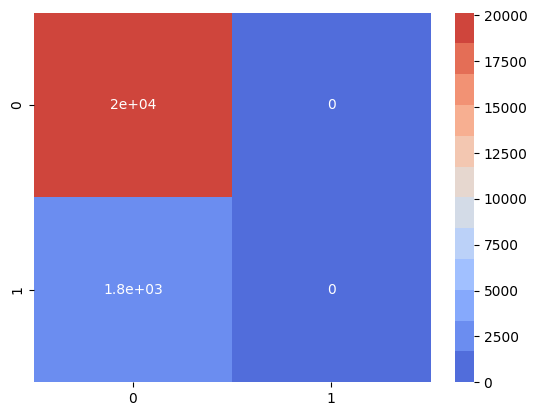

In [ ]:
#Plot Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)
axes = sns.heatmap(cm,annot=True,
                   cmap=sns.color_palette("coolwarm", 12)
                   )
axes

In [ ]:
cm

array([[20152,     0],
       [ 1791,     0]])